# 01 — Data exploration (Phase 1)

Companion notebook for the Phase 1 milestone `results/milestones/m01_data.md`.

**Inputs**: `data/raw/yfinance/{GSPC,VIX,AAPL,TSLA}.parquet` and (when available)
`data/raw/oxfordman/oxfordmanrealizedvolatilityindices.csv`.

**Outputs** (saved to `results/figures/m01/`):
1. ^GSPC log-returns time series with crisis shading
2. Realized-volatility time series (Oxford-Man + Yang-Zhang + squared-returns)
3. Log-returns distribution vs Gaussian
4. ACF of RV (long-memory diagnostic)
5. RV vs |returns| scatter
6. Oxford-Man vs Yang-Zhang sanity-check overlay

and an RV summary table to `results/tables/m01_rv_summary.csv`.

In [1]:
import sys
from pathlib import Path

# Make the project importable when the notebook is run with a bare kernel.
_repo_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.config import load_config, repo_path
from src.utils.io import ensure_dir, from_parquet
from src.utils.plotting import set_style, shade_crises, save_fig
from src.utils.seeding import set_seed
from src.data.realized_vol import (
    log_returns,
    yang_zhang_rv,
    squared_returns_rv,
    realized_vol_from_intraday_rv,
)
from src.data.ingest import load_oxfordman_symbol

cfg = load_config('data')
set_seed(cfg.seed)
set_style()

FIG_DIR = ensure_dir(repo_path('results', 'figures', 'm01'))
TABLE_DIR = ensure_dir(repo_path('results', 'tables'))

## Load data

In [2]:
gspc = from_parquet(repo_path(cfg.paths.yfinance, 'GSPC.parquet'))
vix = from_parquet(repo_path(cfg.paths.yfinance, 'VIX.parquet'))
gspc.index = pd.to_datetime(gspc.index)
vix.index = pd.to_datetime(vix.index)
gspc.head()

,adj_close,close,high,low,open,volume
date,,,,,,
2000-01-03,1455.219971,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1441.469971,1400.729980,1403.449951,1225200000


In [3]:
om_csv = repo_path(cfg.paths.oxfordman, cfg.oxfordman.filename)
if om_csv.exists():
    om = load_oxfordman_symbol(om_csv, symbol=cfg.oxfordman.primary_symbol)
    rv_intraday = realized_vol_from_intraday_rv(om['rv5'])
    print('Oxford-Man rows loaded:', len(rv_intraday),
          '| range:', rv_intraday.index.min().date(), '->', rv_intraday.index.max().date())
else:
    print('Oxford-Man CSV not yet downloaded -- skipping intraday RV section.')
    rv_intraday = None

Oxford-Man rows loaded: 5552 | range: 2000-01-03 -> 2022-02-25


## RV estimators

In [4]:
rv_yz = yang_zhang_rv(gspc, window=21)
rv_sq = squared_returns_rv(gspc['close']).rolling(21).mean()
log_ret = log_returns(gspc['close'])

## Figure 1 — log-return time series with crisis shading

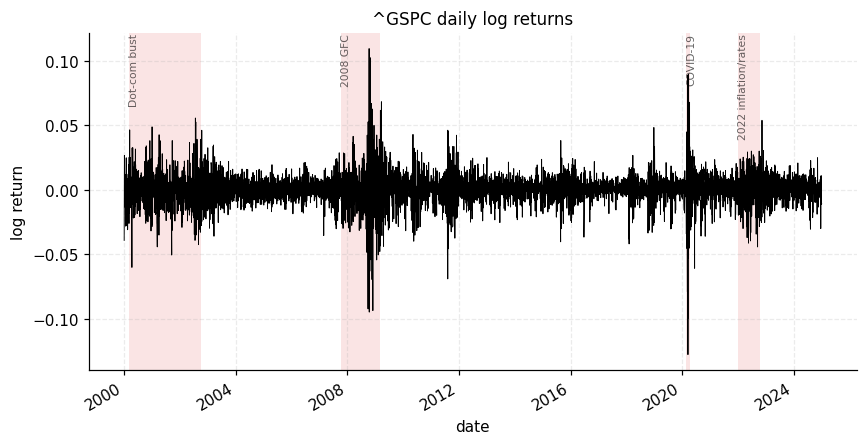

In [5]:
fig, ax = plt.subplots()
log_ret.plot(ax=ax, lw=0.6, color='black')
shade_crises(ax)
ax.set_title('^GSPC daily log returns')
ax.set_ylabel('log return')
save_fig(fig, FIG_DIR / 'fig01_log_returns.png');

## Figure 2 — realized volatility (all three estimators)

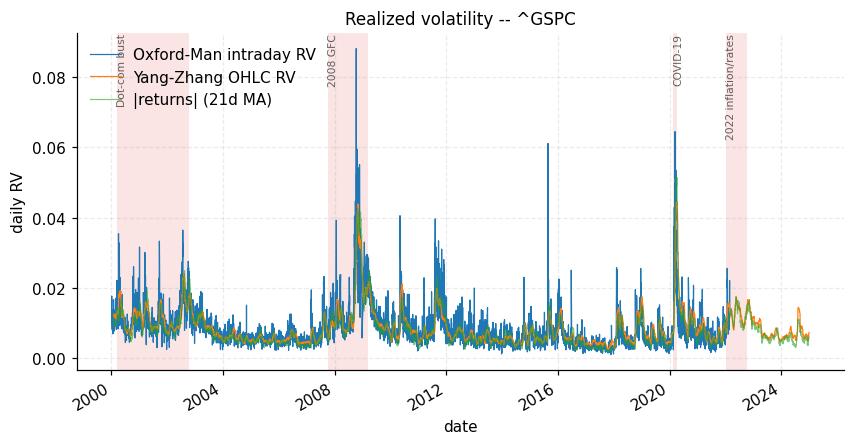

In [6]:
fig, ax = plt.subplots()
if rv_intraday is not None:
    rv_intraday.plot(ax=ax, label='Oxford-Man intraday RV', lw=0.8)
rv_yz.plot(ax=ax, label='Yang-Zhang OHLC RV', lw=0.8)
rv_sq.plot(ax=ax, label='|returns| (21d MA)', lw=0.8, alpha=0.6)
shade_crises(ax)
ax.set_title('Realized volatility -- ^GSPC')
ax.set_ylabel('daily RV')
ax.legend(loc='upper left')
save_fig(fig, FIG_DIR / 'fig02_rv_series.png');

## Figure 3 — log-return distribution vs Gaussian

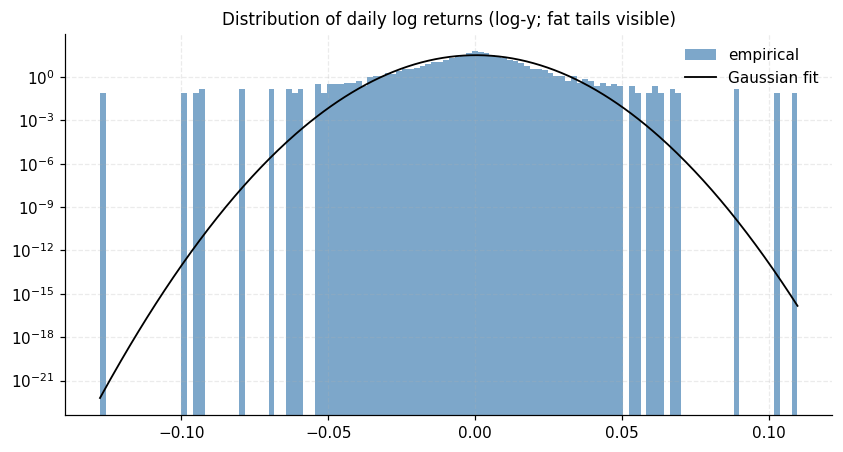

In [7]:
fig, ax = plt.subplots()
r = log_ret.dropna()
ax.hist(r, bins=120, density=True, color='steelblue', alpha=0.7, label='empirical')
xs = np.linspace(r.min(), r.max(), 400)
ax.plot(xs, (1/(np.sqrt(2*np.pi)*r.std())) * np.exp(-0.5*((xs-r.mean())/r.std())**2),
        color='black', lw=1.2, label='Gaussian fit')
ax.set_yscale('log')
ax.set_title('Distribution of daily log returns (log-y; fat tails visible)')
ax.legend()
save_fig(fig, FIG_DIR / 'fig03_returns_distribution.png');

## Figure 4 — ACF of realized volatility (long memory)

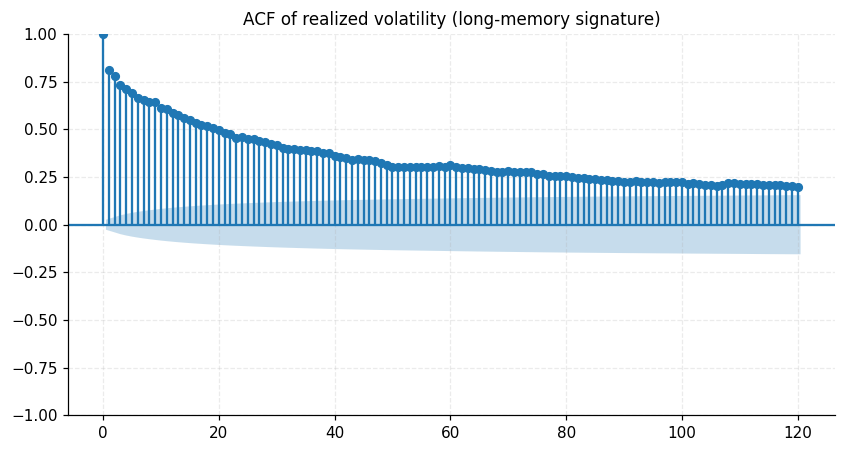

In [8]:
from statsmodels.graphics.tsaplots import plot_acf
rv_for_acf = (rv_intraday if rv_intraday is not None else rv_yz).dropna()
fig, ax = plt.subplots()
plot_acf(rv_for_acf, lags=120, ax=ax)
ax.set_title('ACF of realized volatility (long-memory signature)')
save_fig(fig, FIG_DIR / 'fig04_acf_rv.png');

## Figure 5 — RV vs |returns| scatter

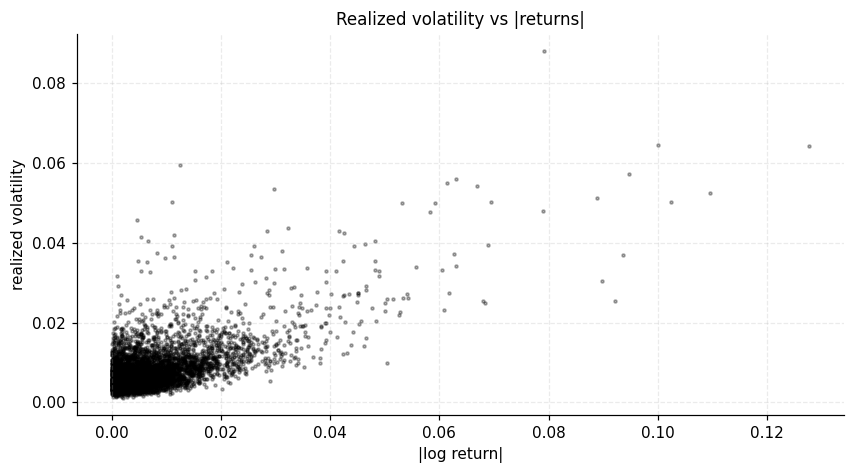

In [9]:
fig, ax = plt.subplots()
joined = pd.concat([
    (rv_intraday if rv_intraday is not None else rv_yz).rename('rv'),
    log_ret.abs().rename('abs_ret'),
], axis=1).dropna()
ax.scatter(joined['abs_ret'], joined['rv'], s=4, alpha=0.3, color='black')
ax.set_xlabel('|log return|')
ax.set_ylabel('realized volatility')
ax.set_title('Realized volatility vs |returns|')
save_fig(fig, FIG_DIR / 'fig05_rv_vs_absret.png');

## Figure 6 — Oxford-Man vs Yang-Zhang sanity check

Pearson correlation (intraday vs YZ): 0.7567
common observations: 4857


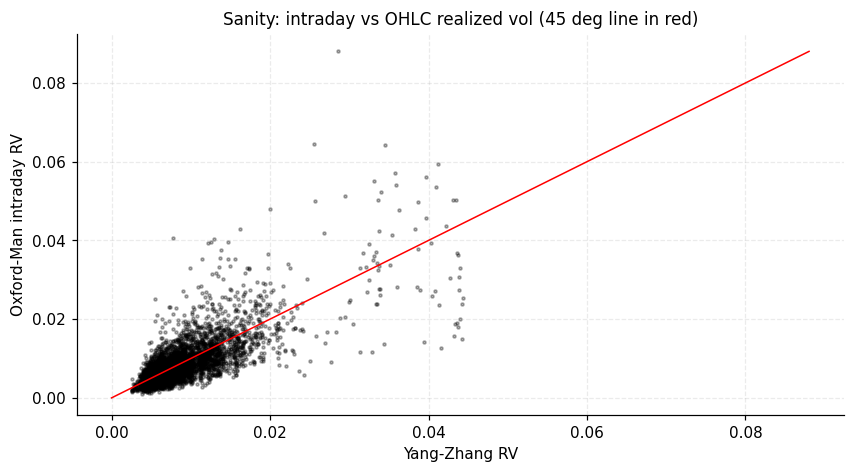

In [10]:
if rv_intraday is not None:
    fig, ax = plt.subplots()
    aligned = pd.concat([rv_intraday.rename('intraday'), rv_yz.rename('yz')], axis=1).dropna()
    ax.scatter(aligned['yz'], aligned['intraday'], s=4, alpha=0.3, color='black')
    lim = float(aligned.to_numpy().max())
    ax.plot([0, lim], [0, lim], color='red', lw=1)
    ax.set_xlabel('Yang-Zhang RV')
    ax.set_ylabel('Oxford-Man intraday RV')
    ax.set_title('Sanity: intraday vs OHLC realized vol (45 deg line in red)')
    save_fig(fig, FIG_DIR / 'fig06_intraday_vs_yz.png')
    print('Pearson correlation (intraday vs YZ):', round(aligned.corr().iloc[0, 1], 4))
    print('common observations:', len(aligned))

## RV summary table

In [11]:
estimators = {'Yang-Zhang OHLC': rv_yz, '|return| 21d MA': rv_sq}
if rv_intraday is not None:
    estimators['Oxford-Man intraday'] = rv_intraday
summary = pd.DataFrame({
    name: {
        'mean': s.mean(), 'median': s.median(), 'std': s.std(),
        'p99': s.quantile(0.99), 'n_obs': int(s.notna().sum()),
    }
    for name, s in estimators.items()
}).T
summary.to_csv(TABLE_DIR / 'm01_rv_summary.csv')
summary

,mean,median,std,p99,n_obs
Yang-Zhang OHLC,0.008656,0.007234,0.004983,0.032322,6267.0
|return| 21d MA,0.008093,0.006676,0.005385,0.035320,6267.0
Oxford-Man intraday,0.008446,0.006842,0.006118,0.033137,5552.0
